# IPF analysis setup and donor-aware helpers

Load shared inputs and define condition normalization, donor mapping, and donor-level aggregation. Donors are the statistical units where donor metadata are available; otherwise samples remain the units.

In [1]:
CELLTYPES = ["AT1", "AT2", "Fibroblast"]
REF_LIST = ["ref1", "ref2", "ref3", "ref4", "ref5", "combined"]
BENCHMARK_METHOD_COLORS = {
    "SABER": "#C95F5F", "DWLS": "#A1C181", "BayesPrism": "#D98C80",
    "Scadenpytorch": "#6B9AC4", "TAPE": "#E0A458", "RNASieve": "#B48EAD",
    "SCDC": "#AFA2D4", "MuSiC": "#B7B7B7", "BisqueRNA": "#F2C6AC", "NNLS": "#9A9A9A",
}
SCATTER_METHOD_DISPLAY_NAMES = {
    "SABER": "SABER",
    "Scadenpytorch": "Scaden",
    "BisqueRNA": "BisqueRNA",
    "RNASieve": "RNASieve",
    "NNLS": "NNLS",
    "TAPE": "TAPE",
    "MuSiC": "MuSiC",
    "SCDC": "SCDC",
    "BayesPrism": "BayesPrism",
    "DWLS": "DWLS",
}
STYLE_BENCHMARK = {
    "font.family": "DejaVu Sans",
    "font.size": 6.5,
    "axes.linewidth": 0.55,
    "axes.labelsize": 6.5,
    "axes.titlesize": 7.5,
    "axes.titleweight": "bold",
    "xtick.labelsize": 5.2,
    "ytick.labelsize": 5.8,
    "legend.fontsize": 6,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 2.2,
    "ytick.major.size": 2.2,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "savefig.bbox": "tight",
}
BENCHMARK_CELLTYPES = [
    "AT1",
    "AT2",
    "Fibroblast",
    "Club",
    "Macrophage",
    "B_cell",
    "SMC",
    "Basal",
    "Dendritic",
    "Monocyte",
    "T_NKT",
    "Mast",
    "Ciliated",
    "Endothelial",
    "Plasma",
]
BULKS_STANDARD = ["IPF1", "IPF2", "IPF3", "IPF5", "IPF6", "IPF7", "IPF8"]
BULKS_WITH_LOC = ["IPF4"]
LOCATIONS = ["Apex", "Base"]
RNASEQ_BULKS = {"IPF1", "IPF2", "IPF3", "IPF4", "IPF5"}
ARRAY_BULKS = {"IPF6", "IPF7", "IPF8"}
PLATFORM_LABELS = {"RNAseq": "RNA-seq", "Array": "Array"}
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import pandas as pd
from scipy.stats import mannwhitneyu
from collections import OrderedDict
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import math
from scipy.stats import pearsonr
import itertools

def normalize_condition(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    label = " ".join(s.lower().replace("_", " ").replace("-", " ").split())
    if label in {"control", "ctrl", "normal", "healthy", "health", "non ipf", "non fibrotic", "nonfibrotic", "donor", "healthy control"}:
        return "Control"
    if label in {"ipf", "idiopathic pulmonary fibrosis", "fibrosis", "pulmonary fibrosis"}:
        return "IPF"
    return s

warnings.filterwarnings("ignore")


## Compare Control and IPF proportions with boxplots

Read matched non-DISSECT predictions, aggregate repeated samples to donors when required, run Mann–Whitney tests, and save the three-panel clinical comparison figures.

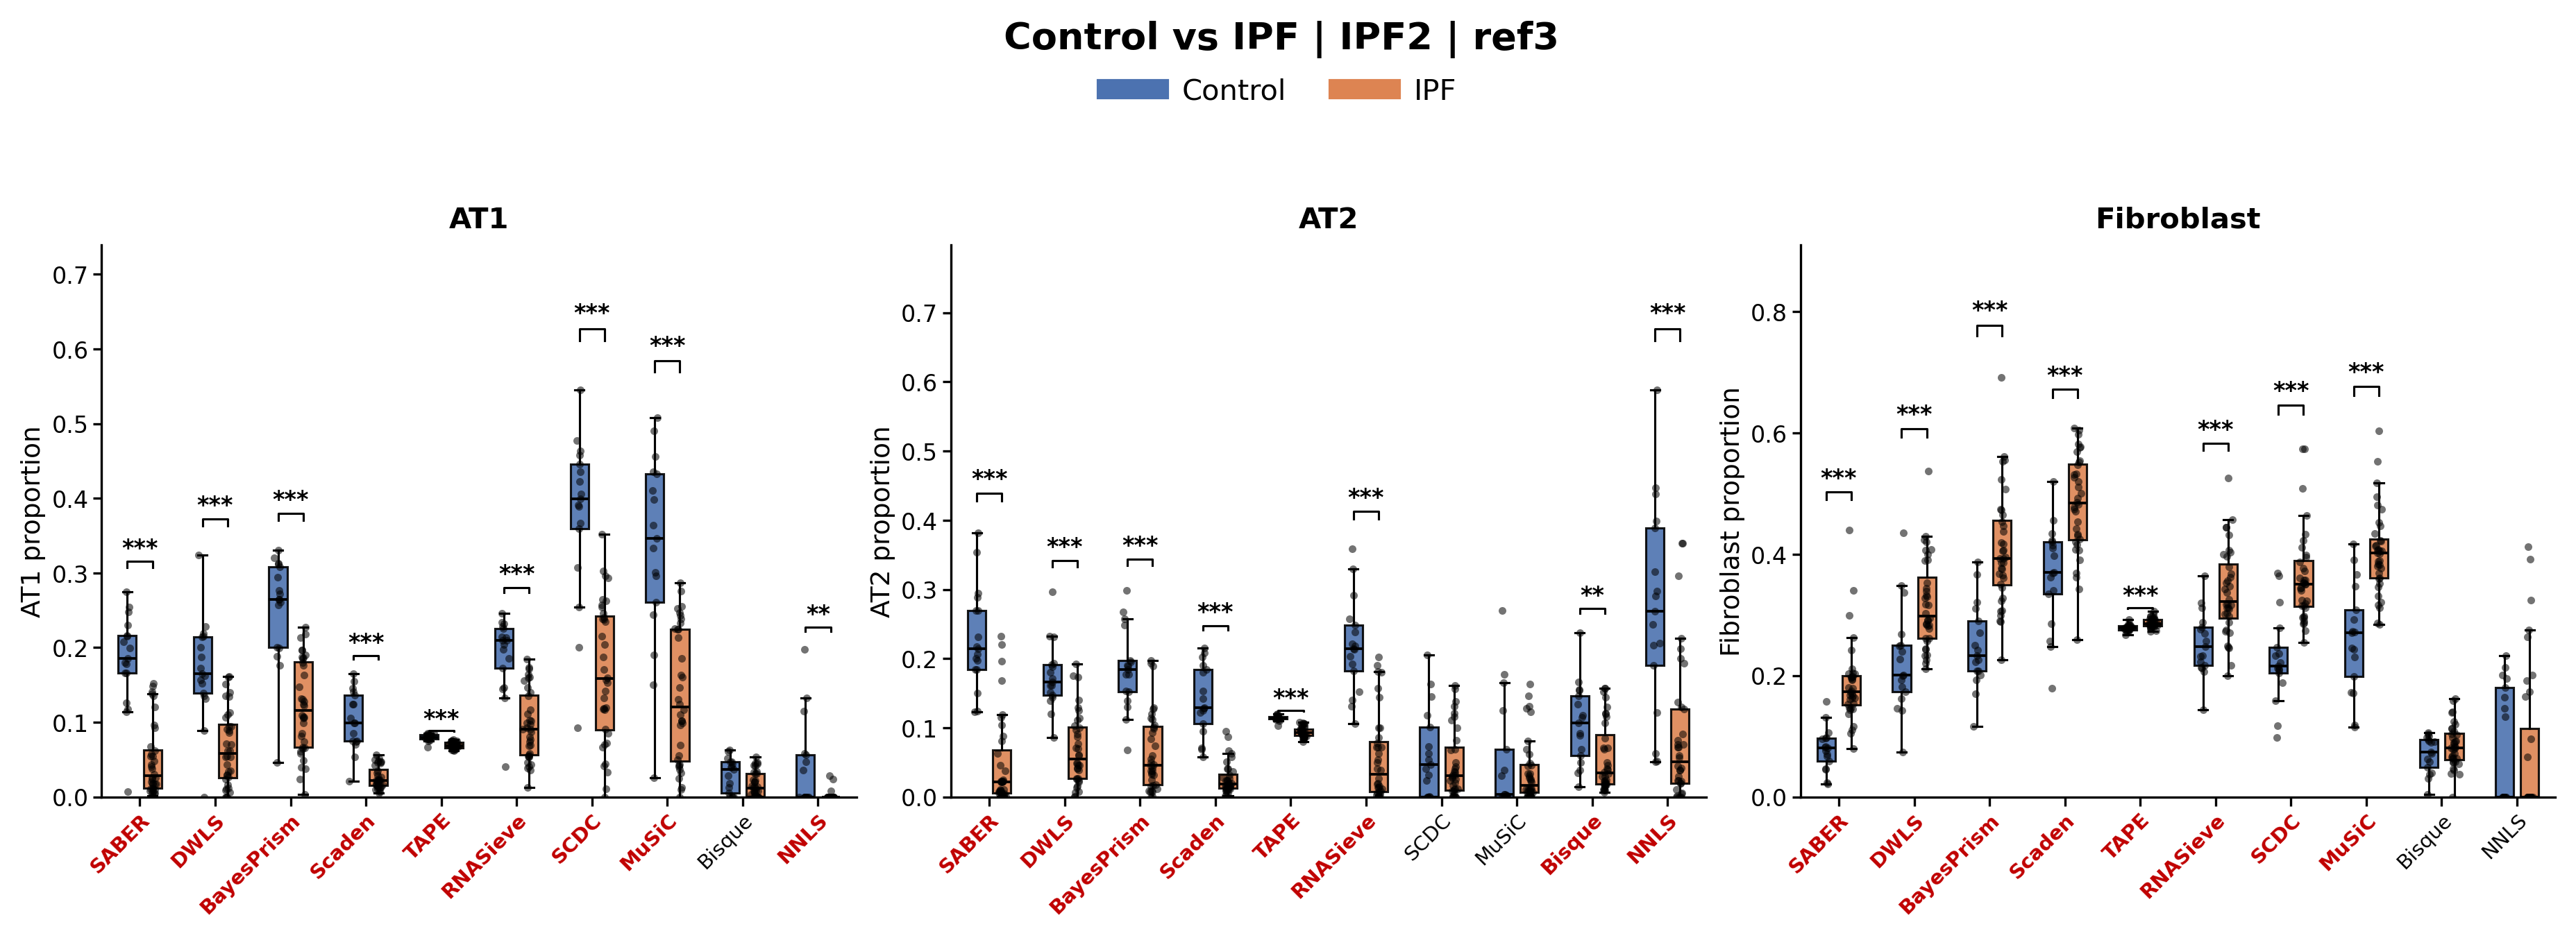

In [2]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 8,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
    }
)
method_list = [
    "SABER",
    "DWLS",
    "BayesPrism",
    "Scadenpytorch",
    "TAPE",
    "RNASieve",
    "SCDC",
    "MuSiC",
    "BisqueRNA",
    "NNLS",
]
method_display_names = {
    "SABER": "SABER",
    "Scadenpytorch": "Scaden",
    "BisqueRNA": "Bisque",
    "RNASieve": "RNASieve",
    "NNLS": "NNLS",
    "TAPE": "TAPE",
    "MuSiC": "MuSiC",
    "SCDC": "SCDC",
    "BayesPrism": "BayesPrism",
    "DWLS": "DWLS",
}
celltypes = CELLTYPES
palette = {"Control": "#4C72B0", "IPF": "#DD8452"}
output_dir = "/Path/to/output/IPF/heatmap"
os.makedirs(output_dir, exist_ok=True)
bulks = {
    "IPF1": {
        "meta_path": "/Path/to/IPF/data/IPF1/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF1",
        "loc_filter": None,
    },
    "IPF2": {
        "meta_path": "/Path/to/IPF/data/IPF2/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF2",
        "loc_filter": None,
    },
    "IPF3": {
        "meta_path": "/Path/to/IPF/data/IPF3/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF3",
        "loc_filter": None,
    },
    "IPF4": {
        "meta_path": "/Path/to/IPF/data/IPF4/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF4",
        "loc_filter": None,
    },
    "IPF4_Apex": {
        "meta_path": "/Path/to/IPF/data/IPF4/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF4",
        "loc_filter": "Apex",
    },
    "IPF4_Base": {
        "meta_path": "/Path/to/IPF/data/IPF4/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF4",
        "loc_filter": "Base",
    },
    "IPF5": {
        "meta_path": "/Path/to/IPF/data/IPF5/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF5",
        "loc_filter": None,
    },
    "IPF6": {
        "meta_path": "/Path/to/IPF/data/IPF6/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF6",
        "loc_filter": None,
    },
    "IPF7": {
        "meta_path": "/Path/to/IPF/data/IPF7/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF7",
        "loc_filter": None,
    },
    "IPF8": {
        "meta_path": "/Path/to/IPF/data/IPF8/metadata.csv",
        "result_dir": "/Path/to/IPF/results/IPF8",
        "loc_filter": None,
    },
}


def p_to_star(p, include_near=False, nan_label="n.s."):
    if pd.isna(p):
        return nan_label
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if include_near and p < 0.1:
        return "near"
    return "n.s."


def get_donor_metadata_info(meta_path):
    norm_meta_path = os.path.normpath(meta_path)
    if norm_meta_path == os.path.normpath("/Path/to/IPF/data/IPF1/metadata.csv"):
        return {
            "dataset": "IPF1",
            "path": "/Path/to/IPF/data/IPF1/GSE124685_metadata.csv",
            "sample_col": "geo_accession",
            "donor_col": "title",
        }
    if norm_meta_path == os.path.normpath("/Path/to/IPF/data/IPF2/metadata.csv"):
        return {
            "dataset": "IPF2",
            "path": "/Path/to/IPF/data/IPF2/GSE134692_design.txt.gz",
            "sample_col": "sample_id",
            "donor_col": "Sample.property",
        }
    if norm_meta_path == os.path.normpath("/Path/to/IPF/data/IPF4/metadata.csv"):
        return {
            "dataset": "IPF4",
            "path": "/Path/to/IPF/data/IPF4/GSE213001_metadata.csv",
            "sample_col": "title",
            "donor_col": "characteristics_ch1.1.donorid",
        }
    return None


def add_donor_id(metadata, meta_path):
    donor_info = get_donor_metadata_info(meta_path)
    if donor_info is None:
        return metadata
    if donor_info["dataset"] == "IPF2":
        donor_metadata = pd.read_csv(donor_info["path"], sep="\t")
    else:
        donor_metadata = pd.read_csv(donor_info["path"])
    metadata = metadata.copy()
    metadata.index = metadata.index.astype(str)
    donor_metadata = donor_metadata.copy()
    donor_metadata[donor_info["sample_col"]] = donor_metadata[donor_info["sample_col"]].astype(str)
    donor_metadata = donor_metadata.set_index(donor_info["sample_col"])
    donor_values = donor_metadata.loc[metadata.index, donor_info["donor_col"]].astype(str)
    if donor_info["dataset"] == "IPF1":
        donor_values = donor_values.str.split(".", regex=False).str[0]
    metadata["donor_id"] = donor_values.values
    return metadata


def aggregate_to_donor_level(df, meta_path, value_columns):
    if get_donor_metadata_info(meta_path) is None:
        return df
    donor_df = df[["donor_id", "condition"] + value_columns].copy()
    donor_df = donor_df.dropna(subset=["donor_id", "condition"])
    for col in value_columns:
        donor_df[col] = pd.to_numeric(donor_df[col], errors="coerce")
    donor_df = donor_df.groupby(["donor_id", "condition"], as_index=False)[value_columns].mean()
    donor_df.index = donor_df["donor_id"].astype(str)
    return donor_df


def draw_subplot(
    ax,
    all_data,
    method_list,
    celltype,
    g1,
    g2,
    title_text,
    palette,
    method_display_names,
    show_ns=False,
    random_seed=0,
):
    rng = np.random.default_rng(random_seed)
    center_spacing = 1.08
    centers = np.arange(len(method_list)) * center_spacing
    offset = 0.18
    box_width = 0.26
    significant_red_indices = []
    significant_blue_indices = []
    global_ymax = None
    global_ymin = None
    for i, method in enumerate(method_list):
        df = all_data.get(method)
        sub1 = pd.to_numeric(df.loc[df["condition"] == g1, celltype], errors="coerce").dropna()
        sub2 = pd.to_numeric(df.loc[df["condition"] == g2, celltype], errors="coerce").dropna()
        assert not (len(sub1) == 0 and len(sub2) == 0)
        pos1 = centers[i] - offset
        pos2 = centers[i] + offset
        bp1 = ax.boxplot(
            [sub1],
            positions=[pos1],
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=0.75, color="black"),
            medianprops=dict(linewidth=0.9, color="black"),
            whiskerprops=dict(linewidth=0.75, color="black"),
            capprops=dict(linewidth=0.75, color="black"),
        )
        for patch in bp1["boxes"]:
            patch.set_facecolor(palette[g1])
            patch.set_alpha(0.9)
            patch.set_edgecolor("black")
        jitter1 = rng.normal(pos1, 0.025, size=len(sub1))
        ax.scatter(
            jitter1, sub1, color="black", s=7, alpha=0.55, linewidths=0, zorder=3, rasterized=True
        )
        this_min = sub1.min()
        this_max = sub1.max()
        global_ymin = this_min if global_ymin is None else min(global_ymin, this_min)
        global_ymax = this_max if global_ymax is None else max(global_ymax, this_max)
        bp2 = ax.boxplot(
            [sub2],
            positions=[pos2],
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(linewidth=0.75, color="black"),
            medianprops=dict(linewidth=0.9, color="black"),
            whiskerprops=dict(linewidth=0.75, color="black"),
            capprops=dict(linewidth=0.75, color="black"),
        )
        for patch in bp2["boxes"]:
            patch.set_facecolor(palette[g2])
            patch.set_alpha(0.9)
            patch.set_edgecolor("black")
        jitter2 = rng.normal(pos2, 0.025, size=len(sub2))
        ax.scatter(
            jitter2, sub2, color="black", s=7, alpha=0.55, linewidths=0, zorder=3, rasterized=True
        )
        this_min = sub2.min()
        this_max = sub2.max()
        global_ymin = this_min if global_ymin is None else min(global_ymin, this_min)
        global_ymax = this_max if global_ymax is None else max(global_ymax, this_max)
        assert len(sub1) >= 2 and len(sub2) >= 2
        _, p = mannwhitneyu(sub1, sub2, alternative="two-sided")
        label = p_to_star(p)
        if p < 0.05:
            mean1 = sub1.mean()
            mean2 = sub2.mean()
            is_opposite = False
            if celltype in ["AT1", "AT2"]:
                if mean2 > mean1:
                    is_opposite = True
            elif celltype == "Fibroblast":
                if mean2 < mean1:
                    is_opposite = True
            if is_opposite:
                significant_blue_indices.append(i)
            else:
                significant_red_indices.append(i)
        if p < 0.05 or show_ns:
            ymax = max(sub1.max(), sub2.max())
            ymin = min(sub1.min(), sub2.min())
            span = ymax - ymin
            h = span * 0.12
            y = ymax + h
            ax.plot(
                [pos1, pos1, pos2, pos2],
                [y, y + h * 0.25, y + h * 0.25, y],
                lw=0.75,
                c="black",
                clip_on=False,
            )
            ax.text(
                (pos1 + pos2) / 2,
                y + h * 0.32,
                label,
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                clip_on=False,
            )
            global_ymax = max(global_ymax, y + h * 0.75)
    ax.set_title(title_text, fontsize=10, fontweight="bold", pad=6)
    ax.set_xticks(centers)
    xtick_labels = ax.set_xticklabels(
        [method_display_names.get(m, m) for m in method_list],
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=7,
    )
    for idx in significant_red_indices:
        if idx < len(xtick_labels):
            xtick_labels[idx].set_color("#C00000")
            xtick_labels[idx].set_fontweight("bold")
    for idx in significant_blue_indices:
        if idx < len(xtick_labels):
            xtick_labels[idx].set_color("#1F4E79")
            xtick_labels[idx].set_fontweight("bold")
    ax.set_ylabel(f"{celltype} proportion", fontsize=9, labelpad=2)
    ax.set_xlim(centers[0] - 0.55, centers[-1] + 0.55)
    ymax = global_ymax
    upper = ymax * 1.12
    ax.set_ylim(0, upper)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=7)


def plot_ipf_3panel(
    selected_bulk,
    selected_ref,
    bulks=bulks,
    method_list=method_list,
    method_display_names=method_display_names,
    celltypes=celltypes,
    palette=palette,
    output_dir=output_dir,
    g1="Control",
    g2="IPF",
    show_ns=False,
    save=True,
    show=True,
):
    bulk_config = bulks[selected_bulk]
    metadata = pd.read_csv(bulk_config["meta_path"], index_col=0)
    metadata = add_donor_id(metadata, bulk_config["meta_path"])
    all_data = {}
    for method in method_list:
        prediction = pd.read_csv(
            os.path.join(bulk_config["result_dir"], f"{method}_{selected_ref}.csv"), index_col=0
        )
        common_samples = metadata.index.intersection(prediction.index)
        data = pd.concat([metadata.loc[common_samples], prediction.loc[common_samples]], axis=1)
        all_data[method] = aggregate_to_donor_level(
            data, bulk_config["meta_path"], prediction.columns.tolist()
        )
    n_cols = len(celltypes)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.2 * n_cols, 4.3), squeeze=False)
    axes = axes[0]
    for i, celltype in enumerate(celltypes):
        ax = axes[i]
        draw_subplot(
            ax=ax,
            all_data=all_data,
            method_list=method_list,
            celltype=celltype,
            g1=g1,
            g2=g2,
            title_text=f"{celltype}",
            palette=palette,
            method_display_names=method_display_names,
            show_ns=show_ns,
            random_seed=i,
        )
    handles = [
        plt.Line2D([0], [0], color=palette[g1], lw=7, label=g1),
        plt.Line2D([0], [0], color=palette[g2], lw=7, label=g2),
    ]
    fig.suptitle(
        f"Control vs IPF | {selected_bulk} | {selected_ref}", fontsize=13, fontweight="bold", y=1.04
    )
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.005),
        ncol=2,
        frameon=False,
        fontsize=10,
        handlelength=1.8,
        columnspacing=1.8,
    )
    for axis in fig.axes:
        axis.tick_params(axis="both", which="both", direction="out", length=3.0, width=0.8, pad=1.5)
        axis.spines["left"].set_linewidth(0.8)
        axis.spines["bottom"].set_linewidth(0.8)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.grid(False)
    fig.tight_layout(rect=[0.01, 0.01, 0.995, 0.93], w_pad=0.6)
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(
        os.path.join(output_dir, f"Control_vs_IPF_3panel_{selected_bulk}_{selected_ref}.pdf"),
        bbox_inches="tight",
    )
    plt.show()
    return (fig, all_data)


fig, all_data = plot_ipf_3panel(selected_bulk="IPF2", selected_ref="ref3")


## Summarize expected IPF directions across datasets

Calculate donor-aware Control–IPF differences for AT1, AT2, and fibroblasts across datasets, locations, methods, and references; save the heatmap and supplementary table.

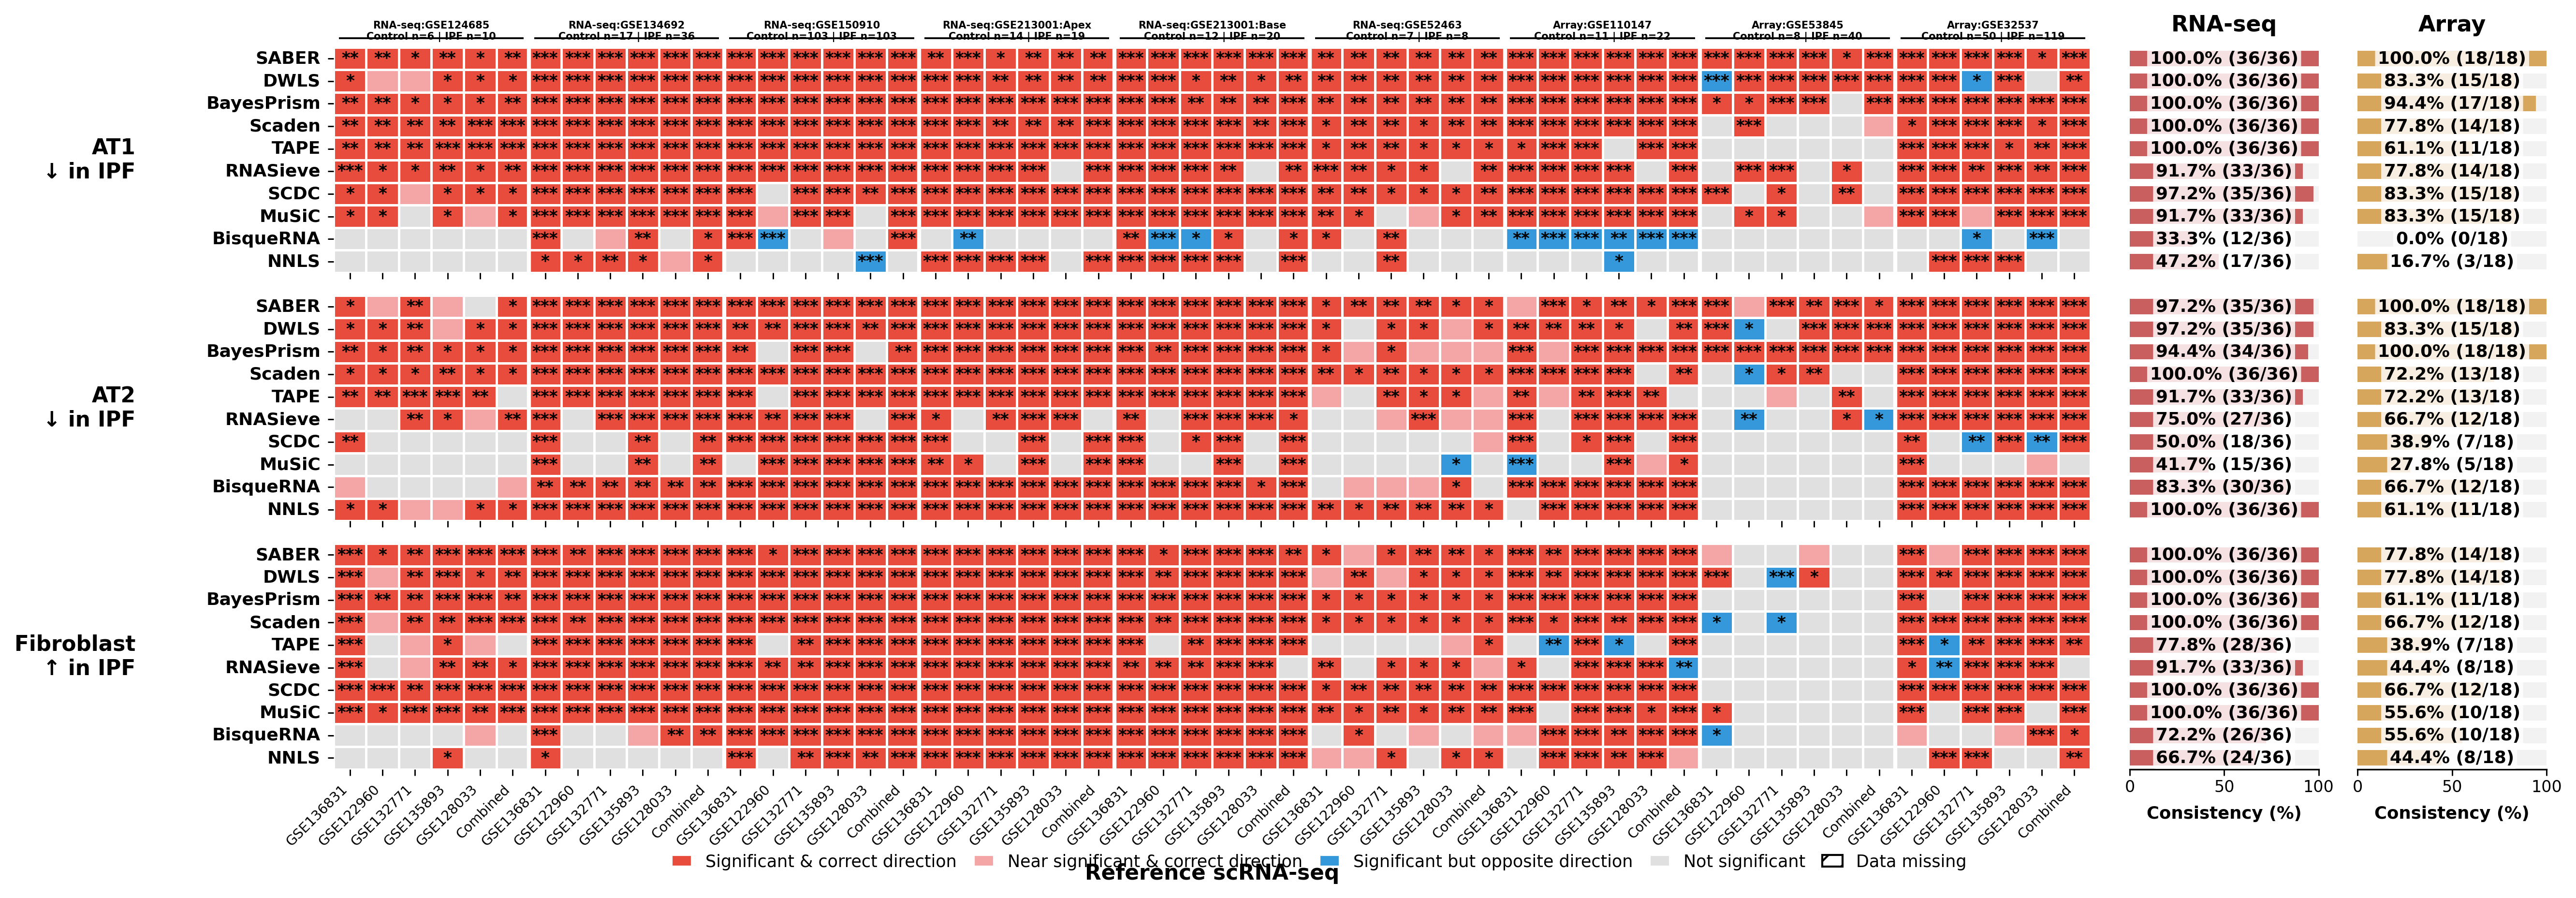

In [3]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 10,
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "text.color": "black",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "legend.frameon": False,
    }
)
methods = [
    {"file_name": "SABER", "display_name": "SABER"},
    {"file_name": "DWLS", "display_name": "DWLS"},
    {"file_name": "BayesPrism", "display_name": "BayesPrism"},
    {"file_name": "Scadenpytorch", "display_name": "Scaden"},
    {"file_name": "TAPE", "display_name": "TAPE"},
    {"file_name": "RNASieve", "display_name": "RNASieve"},
    {"file_name": "SCDC", "display_name": "SCDC"},
    {"file_name": "MuSiC", "display_name": "MuSiC"},
    {"file_name": "BisqueRNA", "display_name": "BisqueRNA"},
    {"file_name": "NNLS", "display_name": "NNLS"},
]
method_file_list = [m["file_name"] for m in methods]
method_display_list = [m["display_name"] for m in methods]
celltypes = CELLTYPES
expected_direction = {"AT1": "down", "AT2": "down", "Fibroblast": "up"}
refs = OrderedDict(
    [
        ("ref1", "GSE136831"),
        ("ref2", "GSE122960"),
        ("ref3", "GSE132771"),
        ("ref4", "GSE135893"),
        ("ref5", "GSE128033"),
        ("combined", "Combined"),
    ]
)
bulk_datasets = OrderedDict(
    [
        ("IPF1", {"display_label": "RNA-seq:GSE124685"}),
        ("IPF2", {"display_label": "RNA-seq:GSE134692"}),
        ("IPF3", {"display_label": "RNA-seq:GSE150910"}),
        ("IPF4", {"display_label": "RNA-seq:GSE213001"}),
        ("IPF5", {"display_label": "RNA-seq:GSE52463"}),
        ("IPF6", {"display_label": "Array:GSE110147"}),
        ("IPF7", {"display_label": "Array:GSE53845"}),
        ("IPF8", {"display_label": "Array:GSE32537"}),
    ]
)
location_datasets = {"IPF4": ["Apex", "Base"]}
scenarios = OrderedDict()
for bulk_key, bulk_info in bulk_datasets.items():
    if bulk_key in location_datasets:
        for loc in location_datasets[bulk_key]:
            for ref_key, ref_label in refs.items():
                s_name = f"{bulk_key}_{loc}_{ref_key}"
                scenarios[s_name] = {
                    "bulk_key": bulk_key,
                    "ref_key": ref_key,
                    "bulk_display": f"{bulk_info['display_label']}:{loc}",
                    "ref_display": ref_label,
                    "meta_path": f"/Path/to/IPF/data/{bulk_key}/metadata.csv",
                    "result_dir": f"/Path/to/IPF/results/{bulk_key}",
                    "g1": "Control",
                    "g2": "IPF",
                    "location_filter": loc,
                }
    else:
        for ref_key, ref_label in refs.items():
            s_name = f"{bulk_key}_{ref_key}"
            scenarios[s_name] = {
                "bulk_key": bulk_key,
                "ref_key": ref_key,
                "bulk_display": bulk_info["display_label"],
                "ref_display": ref_label,
                "meta_path": f"/Path/to/IPF/data/{bulk_key}/metadata.csv",
                "result_dir": f"/Path/to/IPF/results/{bulk_key}",
                "g1": "Control",
                "g2": "IPF",
                "location_filter": None,
            }
scenario_names = list(scenarios.keys())


def get_analysis_point_counts(cfg):
    metadata = pd.read_csv(cfg["meta_path"], index_col=0)
    metadata.index = metadata.index.astype(str)
    metadata["condition"] = metadata["condition"].map(normalize_condition)
    metadata = add_donor_id(metadata, cfg["meta_path"])
    if cfg["location_filter"] is not None:
        metadata = metadata[metadata["location"] == cfg["location_filter"]].copy()
    if "donor_id" in metadata.columns:
        unit_df = metadata[["donor_id", "condition"]].dropna().drop_duplicates()
    else:
        unit_df = metadata[["condition"]].dropna().copy()
    counts = unit_df["condition"].value_counts()
    return {cfg["g1"]: int(counts.get(cfg["g1"], 0)), cfg["g2"]: int(counts.get(cfg["g2"], 0))}


p_values_dict = {
    ct: {m: {s: np.nan for s in scenario_names} for m in method_file_list} for ct in celltypes
}
diff_dict = {
    ct: {m: {s: np.nan for s in scenario_names} for m in method_file_list} for ct in celltypes
}
control_n_dict = {
    ct: {m: {s: np.nan for s in scenario_names} for m in method_file_list} for ct in celltypes
}
ipf_n_dict = {
    ct: {m: {s: np.nan for s in scenario_names} for m in method_file_list} for ct in celltypes
}
for s_name, cfg in scenarios.items():
    metadata = pd.read_csv(cfg["meta_path"], index_col=0)
    metadata.index = metadata.index.astype(str)
    metadata["condition"] = metadata["condition"].map(normalize_condition)
    metadata = add_donor_id(metadata, cfg["meta_path"])
    if cfg["location_filter"] is not None:
        metadata = metadata[metadata["location"] == cfg["location_filter"]].copy()
    g1 = cfg["g1"]
    g2 = cfg["g2"]
    ref_key = cfg["ref_key"]
    for method in method_file_list:
        pred_path = os.path.join(cfg["result_dir"], f"{method}_{ref_key}.csv")
        pred = pd.read_csv(pred_path, index_col=0)
        pred.index = pred.index.astype(str)
        common = metadata.index.intersection(pred.index)
        df = pd.concat([metadata.loc[common], pred.loc[common]], axis=1)
        for celltype in celltypes:
            df[celltype] = pd.to_numeric(df[celltype], errors="coerce")
            test_df = aggregate_to_donor_level(df, cfg["meta_path"], [celltype])
            sub1 = test_df.loc[test_df["condition"] == g1, celltype].dropna()
            sub2 = test_df.loc[test_df["condition"] == g2, celltype].dropna()
            assert len(sub1) > 0 and len(sub2) > 0
            _, p = mannwhitneyu(sub1, sub2, alternative="two-sided")
            diff = sub2.mean() - sub1.mean()
            p_values_dict[celltype][method][s_name] = p
            diff_dict[celltype][method][s_name] = diff
            control_n_dict[celltype][method][s_name] = len(sub1)
            ipf_n_dict[celltype][method][s_name] = len(sub2)


def build_matrix_for_celltype(celltype):
    sig_matrix = pd.DataFrame(index=method_file_list, columns=scenario_names, dtype=float)
    annot_matrix = pd.DataFrame(index=method_file_list, columns=scenario_names, dtype=object)
    for method in method_file_list:
        for s in scenario_names:
            p = p_values_dict[celltype][method][s]
            diff = diff_dict[celltype][method][s]
            assert not (pd.isna(p) or pd.isna(diff))
            is_sig = p < 0.05
            is_trend = 0.05 <= p < 0.1
            if expected_direction[celltype] == "up":
                is_correct_dir = diff > 0
            else:
                is_correct_dir = diff < 0
            if is_sig and is_correct_dir:
                sig_matrix.loc[method, s] = 3.0
                annot_matrix.loc[method, s] = p_to_star(p, include_near=True, nan_label="NA")
            elif is_trend and is_correct_dir:
                sig_matrix.loc[method, s] = 2.0
                annot_matrix.loc[method, s] = ""
            elif is_sig and (not is_correct_dir):
                sig_matrix.loc[method, s] = 0.0
                annot_matrix.loc[method, s] = p_to_star(p, include_near=True, nan_label="NA")
            else:
                sig_matrix.loc[method, s] = 1.0
                annot_matrix.loc[method, s] = ""
    correct_or_trend = (sig_matrix == 3.0) | (sig_matrix == 2.0)
    rnaseq_scenarios = [
        s
        for s in scenario_names
        if scenarios[s]["bulk_key"] in {"IPF1", "IPF2", "IPF3", "IPF4", "IPF5"}
    ]
    array_scenarios = [
        s for s in scenario_names if scenarios[s]["bulk_key"] in {"IPF6", "IPF7", "IPF8"}
    ]
    rnaseq_scores = correct_or_trend[rnaseq_scenarios].sum(axis=1).astype(int)
    array_scores = correct_or_trend[array_scenarios].sum(axis=1).astype(int)
    rnaseq_total = len(rnaseq_scenarios)
    array_total = len(array_scenarios)
    rnaseq_percentages = rnaseq_scores / rnaseq_total * 100
    array_percentages = array_scores / array_total * 100
    sig_matrix.index = method_display_list
    annot_matrix.index = method_display_list
    ref_labels = [scenarios[s]["ref_display"] for s in scenario_names]
    sig_matrix.columns = ref_labels
    annot_matrix.columns = ref_labels
    score_summary = pd.DataFrame(
        {
            "RNA-seq_score": rnaseq_scores.to_numpy(),
            "RNA-seq_total": rnaseq_total,
            "RNA-seq_percentage": rnaseq_percentages.to_numpy(),
            "Array_score": array_scores.to_numpy(),
            "Array_total": array_total,
            "Array_percentage": array_percentages.to_numpy(),
        },
        index=method_display_list,
    )
    return (sig_matrix, annot_matrix, score_summary)


bulk_count_labels = OrderedDict()
for s_name in scenario_names:
    bulk_label = scenarios[s_name]["bulk_display"]
    if bulk_label in bulk_count_labels:
        continue
    counts = get_analysis_point_counts(scenarios[s_name])
    bulk_count_labels[bulk_label] = f"Control n={counts['Control']} | IPF n={counts['IPF']}"
bulk_to_cols = OrderedDict()
for i, s in enumerate(scenario_names):
    bulk = scenarios[s]["bulk_display"]
    bulk_to_cols.setdefault(bulk, []).append(i)
cmap = ListedColormap(["#3498DB", "#E0E0E0", "#F4A6A6", "#E74C3C", "#FFFFFF"])


def draw_percentage_bar(
    ax, percentages, scores, total, title, bar_color, show_title=True, show_xaxis=True
):
    percentages = np.asarray(percentages, dtype=float)
    scores = np.asarray(scores, dtype=int)
    y_positions = np.arange(len(percentages)) + 0.5
    ax.barh(
        y_positions,
        np.full(len(percentages), 100.0),
        height=0.68,
        color="#F2F2F2",
        edgecolor="none",
        zorder=1,
    )
    ax.barh(y_positions, percentages, height=0.68, color=bar_color, edgecolor="none", zorder=2)
    for y, percentage, score in zip(y_positions, percentages, scores):
        ax.text(
            50.0,
            y,
            f"{percentage:.1f}% ({score}/{total})",
            ha="center",
            va="center",
            fontsize=8.6,
            fontweight="bold",
            color="black",
            bbox={
                "boxstyle": "round,pad=0.16",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.82,
            },
            zorder=3,
        )
    ax.set_xlim(0, 100)
    ax.set_ylim(len(percentages), 0)
    ax.set_yticks([])
    ax.grid(False)
    if show_title:
        ax.set_title(title, fontsize=11.0, fontweight="bold", color="black", pad=8)
    else:
        ax.set_title("")
    if show_xaxis:
        ax.set_xticks([0, 50, 100])
        ax.set_xticklabels(["0", "50", "100"], fontsize=8.0)
        ax.tick_params(axis="x", length=2.5, width=0.7, color="black", labelcolor="black", pad=2)
        ax.set_xlabel("Consistency (%)", fontsize=8.5, fontweight="bold", color="black", labelpad=5)
    else:
        ax.set_xticks([])
        ax.set_xlabel("")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    if show_xaxis:
        ax.spines["bottom"].set_visible(True)
        ax.spines["bottom"].set_linewidth(0.8)
        ax.spines["bottom"].set_color("black")
    else:
        ax.spines["bottom"].set_visible(False)


def plot_combined_celltype_heatmap():
    n_celltypes = len(celltypes)
    fig = plt.figure(figsize=(17.2, 6.3))
    fig.patch.set_facecolor("white")
    grid = fig.add_gridspec(
        nrows=n_celltypes, ncols=3, width_ratios=[20.0, 2.15, 2.15], hspace=0.1, wspace=0.055
    )
    for row_idx, celltype in enumerate(celltypes):
        sig_matrix, annot_matrix, score_summary = build_matrix_for_celltype(celltype)
        ax = fig.add_subplot(grid[row_idx, 0])
        ax_rnaseq = fig.add_subplot(grid[row_idx, 1])
        ax_array = fig.add_subplot(grid[row_idx, 2])
        ax.set_facecolor("white")
        ax_rnaseq.set_facecolor("white")
        ax_array.set_facecolor("white")
        sns.heatmap(
            sig_matrix,
            cmap=cmap,
            norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N),
            annot=annot_matrix,
            fmt="",
            cbar=False,
            linewidths=0.8,
            linecolor="white",
            yticklabels=method_display_list,
            annot_kws={"size": 8.2, "weight": "bold", "color": "black"},
            ax=ax,
        )
        for text in ax.texts:
            text.set_color("black")
            text.set_fontweight("bold")
        draw_percentage_bar(
            ax=ax_rnaseq,
            percentages=score_summary["RNA-seq_percentage"].to_numpy(),
            scores=score_summary["RNA-seq_score"].to_numpy(),
            total=int(score_summary["RNA-seq_total"].iloc[0]),
            title="RNA-seq",
            bar_color="#C95F5F",
            show_title=row_idx == 0,
            show_xaxis=row_idx == n_celltypes - 1,
        )
        draw_percentage_bar(
            ax=ax_array,
            percentages=score_summary["Array_percentage"].to_numpy(),
            scores=score_summary["Array_score"].to_numpy(),
            total=int(score_summary["Array_total"].iloc[0]),
            title="Array",
            bar_color="#D6A65C",
            show_title=row_idx == 0,
            show_xaxis=row_idx == n_celltypes - 1,
        )
        direction_symbol = "↑" if expected_direction[celltype] == "up" else "↓"
        ax.set_ylabel(
            f"{celltype}\n{direction_symbol} in IPF",
            fontsize=10.5,
            fontweight="bold",
            color="black",
            rotation=0,
            ha="right",
            va="center",
            labelpad=35,
        )
        if row_idx == n_celltypes - 1:
            ax.tick_params(axis="x", rotation=45, labelsize=6.8, length=0, colors="black")
            ax.set_xlabel(
                "Reference scRNA-seq", fontsize=10.5, fontweight="bold", color="black", labelpad=7
            )
            for tick in ax.get_xticklabels():
                tick.set_ha("right")
                tick.set_color("black")
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis="x", length=0, labelbottom=False)
            ax.set_xlabel("")
        ax.tick_params(axis="y", rotation=0, labelsize=8.7, length=0, colors="black")
        for tick in ax.get_yticklabels():
            tick.set_fontweight("bold")
            tick.set_color("black")
        n_methods = len(method_file_list)
        for bulk_label, col_indices in bulk_to_cols.items():
            start_col = col_indices[0]
            end_col = col_indices[-1]
            x_center = (start_col + end_col + 1) / 2
            if row_idx == 0:
                ax.text(
                    x_center,
                    -0.72,
                    f"{bulk_label}\n{bulk_count_labels.get(bulk_label, '')}",
                    ha="center",
                    va="center",
                    fontsize=5.0,
                    fontweight="bold",
                    color="black",
                    clip_on=False,
                )
                ax.hlines(
                    y=-0.4,
                    xmin=start_col + 0.16,
                    xmax=end_col + 0.84,
                    colors="black",
                    linewidth=0.9,
                    clip_on=False,
                )
            if start_col > 0:
                ax.vlines(x=start_col, ymin=0, ymax=n_methods, colors="white", linewidth=2.0)
        for text in ax.texts:
            text.set_color("black")
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.legend(
        handles=[
            Patch(facecolor="#E74C3C", edgecolor="white", label="Significant & correct direction"),
            Patch(
                facecolor="#F4A6A6", edgecolor="white", label="Near significant & correct direction"
            ),
            Patch(
                facecolor="#3498DB", edgecolor="white", label="Significant but opposite direction"
            ),
            Patch(facecolor="#E0E0E0", edgecolor="white", label="Not significant"),
            Patch(facecolor="white", edgecolor="black", hatch="//", label="Data missing"),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.008),
        ncol=5,
        frameon=False,
        fontsize=8.4,
        handlelength=1.2,
        columnspacing=1.0,
    )
    for text in fig.texts:
        text.set_color("black")
    fig.subplots_adjust(left=0.105, right=0.992, top=0.925, bottom=0.135)
    fig.patch.set_facecolor("white")
    for axis in fig.axes:
        axis.set_facecolor("white")
        axis.tick_params(axis="both", length=3, width=0.7, color="black", labelcolor="black")
        for spine in axis.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color("black")
        axis.xaxis.label.set_color("black")
        axis.yaxis.label.set_color("black")
        axis.title.set_color("black")
        for text in axis.texts:
            text.set_color("black")
    save_dir = "/Path/to/output/IPF/heatmap"
    os.makedirs(save_dir, exist_ok=True)
    pdf_path = os.path.join(save_dir, "IPF_AT1_AT2_Fibroblast_consistency_heatmap.pdf")
    plt.savefig(pdf_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


plot_combined_celltype_heatmap()
records = []
for celltype in celltypes:
    for method, display_name in zip(method_file_list, method_display_list):
        for s_name, cfg in scenarios.items():
            p = p_values_dict[celltype][method][s_name]
            diff = diff_dict[celltype][method][s_name]
            assert not (pd.isna(p) or pd.isna(diff))
            is_sig = p < 0.05
            is_trend = 0.05 <= p < 0.1
            if expected_direction[celltype] == "up":
                is_correct = diff > 0
            else:
                is_correct = diff < 0
            if is_sig and is_correct:
                result = "Correct_significant"
            elif is_trend and is_correct:
                result = "Correct_near"
            elif is_sig and (not is_correct):
                result = "Opposite_significant"
            else:
                result = "Not_significant"
            bulk_dataset = bulk_datasets[cfg["bulk_key"]]["display_label"].split(":")[-1]
            records.append(
                {
                    "Celltype": celltype,
                    "Method": display_name,
                    "Bulk_dataset": bulk_dataset,
                    "Location": cfg["location_filter"]
                    if cfg["location_filter"] is not None
                    else "",
                    "Reference": cfg["ref_display"],
                    "Control_n": control_n_dict[celltype][method][s_name],
                    "IPF_n": ipf_n_dict[celltype][method][s_name],
                    "Difference": diff,
                    "P_value": p,
                    "Result": result,
                }
            )
supplementary_df = pd.DataFrame(
    records,
    columns=[
        "Celltype",
        "Method",
        "Bulk_dataset",
        "Location",
        "Reference",
        "Control_n",
        "IPF_n",
        "Difference",
        "P_value",
        "Result",
    ],
)
save_dir = "/Path/to/output/IPF/heatmap"
os.makedirs(save_dir, exist_ok=True)
supplementary_path = os.path.join(save_dir, "Supplementary_Data_IPF_clinical_validation.csv")
supplementary_df.to_csv(supplementary_path, index=False, na_rep="NA")
for celltype in celltypes:
    df_print = pd.DataFrame(index=method_display_list, columns=scenario_names)
    for method, display_name in zip(method_file_list, method_display_list):
        for s in scenario_names:
            p = p_values_dict[celltype][method][s]
            diff = diff_dict[celltype][method][s]
            assert not (pd.isna(p) or pd.isna(diff))
            is_sig = p < 0.05
            is_trend = 0.05 <= p < 0.1
            if expected_direction[celltype] == "up":
                is_correct = diff > 0
            else:
                is_correct = diff < 0
            star = p_to_star(p, include_near=True, nan_label="NA")
            if is_sig and is_correct:
                df_print.loc[display_name, s] = f"{star} Correct, diff={diff:.3f}"
            elif is_trend and is_correct:
                df_print.loc[display_name, s] = f"{star} Near correct, diff={diff:.3f}"
            elif is_sig and (not is_correct):
                df_print.loc[display_name, s] = f"{star} Opposite, diff={diff:.3f}"
            else:
                df_print.loc[display_name, s] = f"n.s., diff={diff:.3f}"


## Plot IPF cross-reference scatter consistency

Compare predictions across references for matched samples and cell types, including BisqueRNA, and save raw/summary consistency outputs and scatter panels.

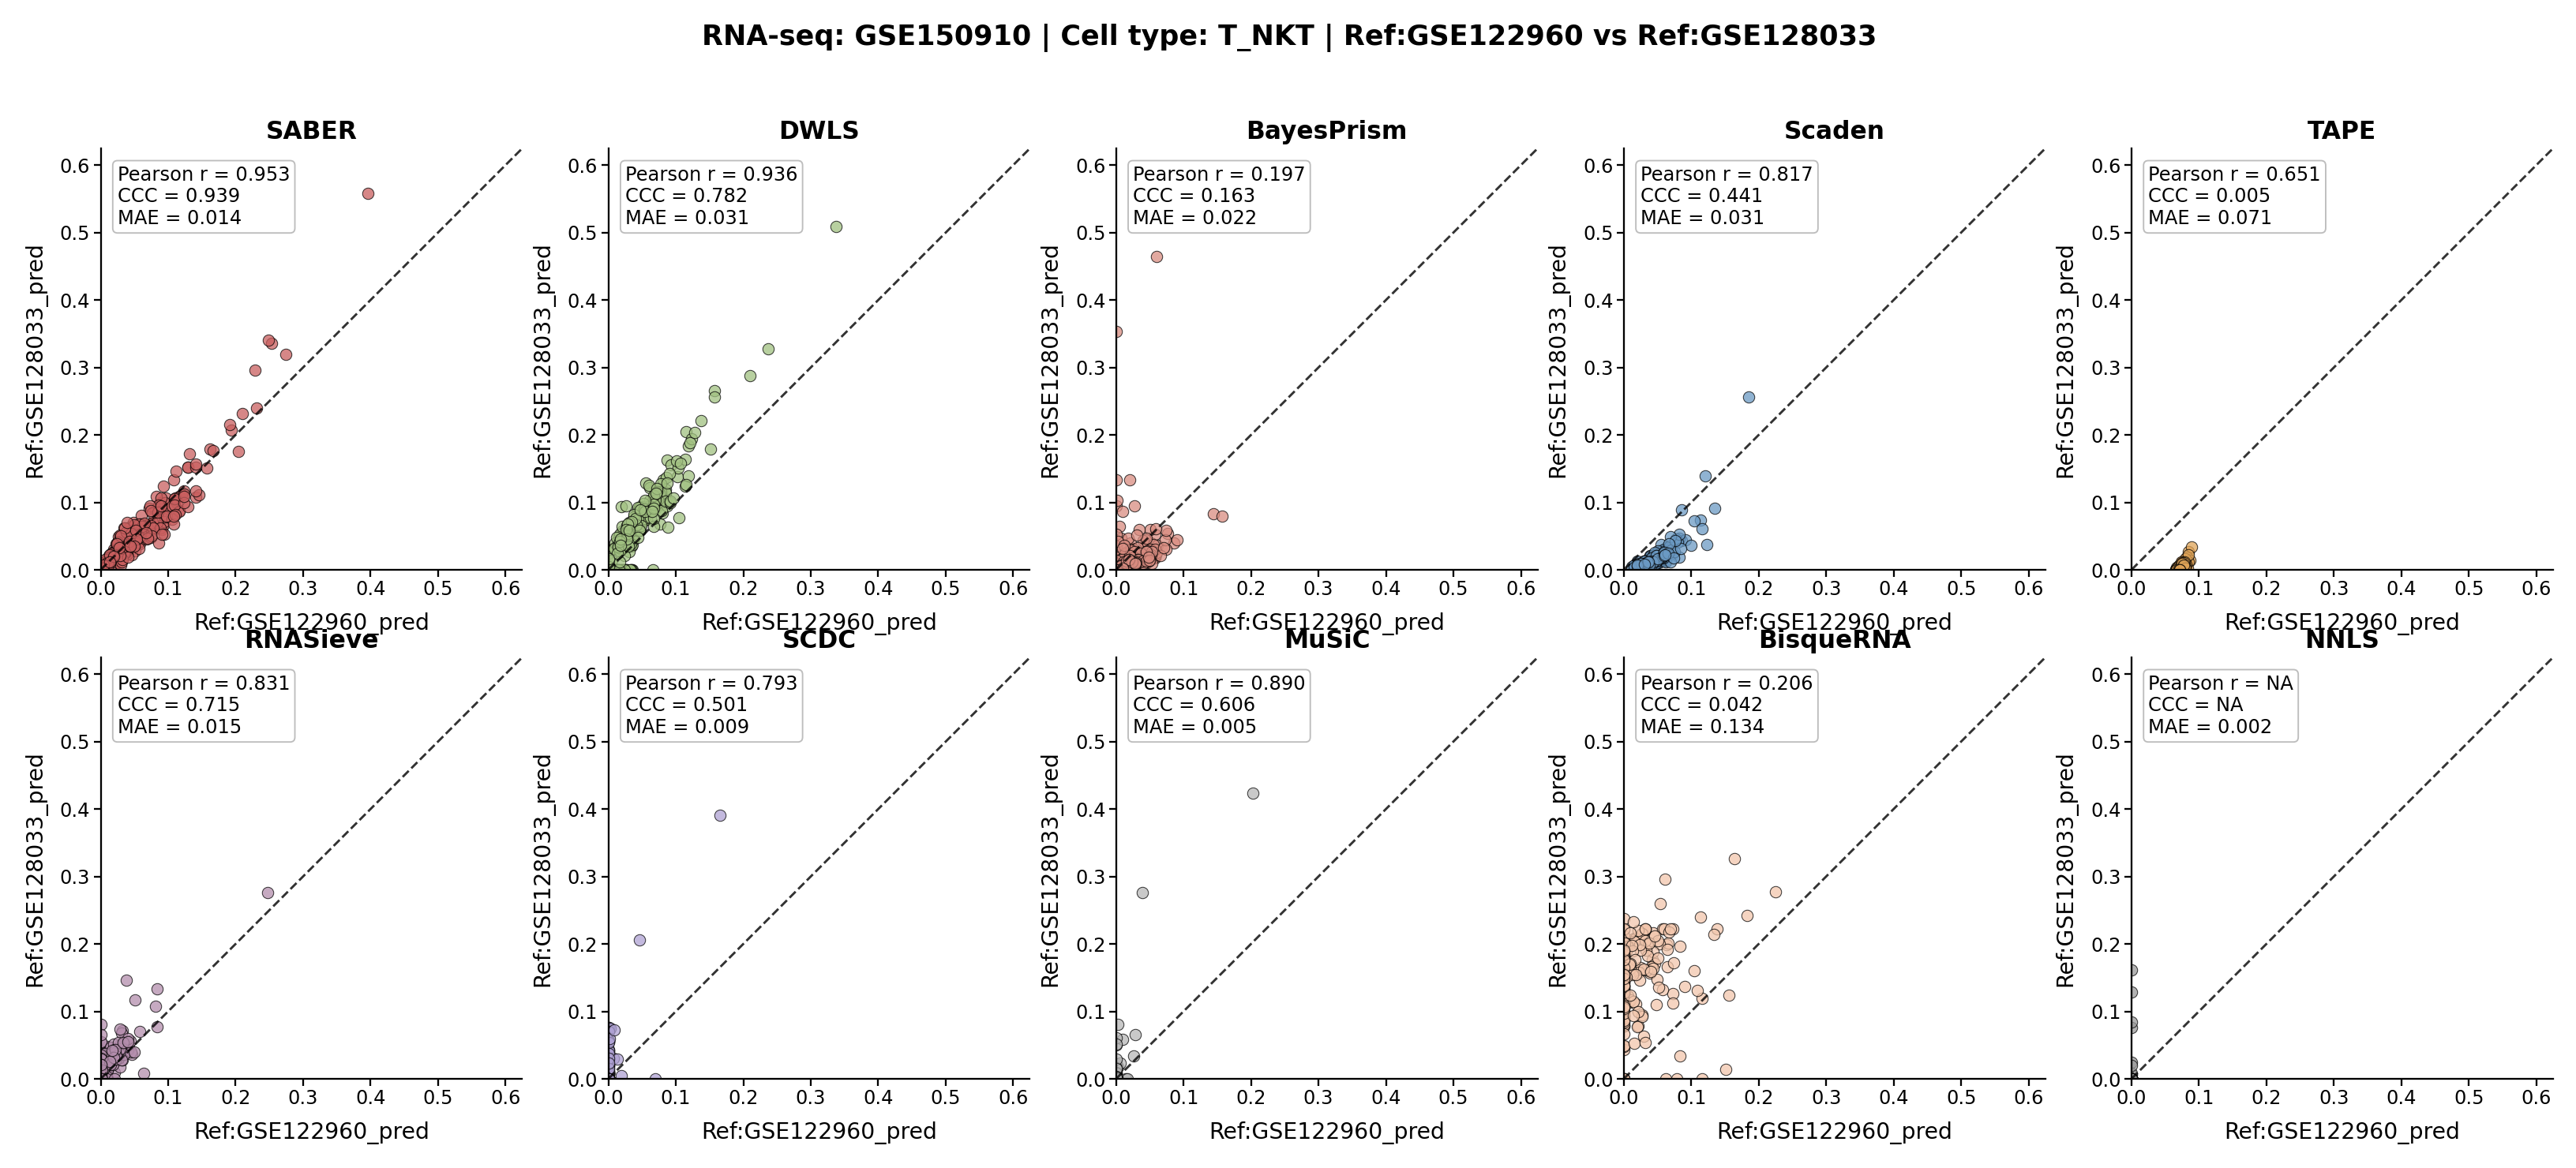

,Bulk,Dataset,CellType,Method,Ref_A,Ref_B,Ref_A_Display,Ref_B_Display,N,PearsonR,CCC,MAE
0,IPF3,RNA-seq: GSE150910,T_NKT,SABER,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.952876,0.939301,0.014168
1,IPF3,RNA-seq: GSE150910,T_NKT,DWLS,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.935636,0.782388,0.030529
2,IPF3,RNA-seq: GSE150910,T_NKT,BayesPrism,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.197444,0.162587,0.021586
3,IPF3,RNA-seq: GSE150910,T_NKT,Scadenpytorch,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.817029,0.441141,0.030575
4,IPF3,RNA-seq: GSE150910,T_NKT,TAPE,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.650974,0.004925,0.070985
5,IPF3,RNA-seq: GSE150910,T_NKT,RNASieve,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.831358,0.715090,0.015027
6,IPF3,RNA-seq: GSE150910,T_NKT,SCDC,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.793213,0.500579,0.008684
7,IPF3,RNA-seq: GSE150910,T_NKT,MuSiC,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.890293,0.606236,0.004912
8,IPF3,RNA-seq: GSE150910,T_NKT,BisqueRNA,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,0.205735,0.041751,0.133710
9,IPF3,RNA-seq: GSE150910,T_NKT,NNLS,ref2,ref5,Ref:GSE122960,Ref:GSE128033,206,NaN,NaN,0.002460


In [4]:
BULK = "IPF3"
REF_A = "ref2"
REF_B = "ref5"
CELLTYPE = "T_NKT"
METHOD_LIST = (
    ["SABER", "DWLS", "BayesPrism", "Scadenpytorch", "TAPE", "RNASieve", "SCDC", "MuSiC", "BisqueRNA", "NNLS"]
)
DATASET_DISPLAY = "RNA-seq: GSE150910"
REF_DISPLAY_NAMES = (
    {
        "ref1": "Ref:GSE136831",
        "ref2": "Ref:GSE122960",
        "ref3": "Ref:GSE132771",
        "ref4": "Ref:GSE135893",
        "ref5": "Ref:GSE128033",
        "combined": "Combined",
    }
)
RESULT_DIR = os.path.join("/Path/to/IPF/results", BULK)
FILE_TEMPLATE = "{method}_{ref}.csv"
OUTPUT_DIR = "/Path/to/output/IPF/consistency_scatter"
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 6.5,
        "axes.linewidth": 0.55,
        "axes.labelsize": 6.8,
        "axes.titlesize": 7.5,
        "axes.titleweight": "bold",
        "xtick.labelsize": 5.8,
        "ytick.labelsize": 5.8,
        "legend.fontsize": 6,
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 2.2,
        "ytick.major.size": 2.2,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
        "savefig.bbox": "tight",
    }
)
REF_A_DISPLAY = REF_DISPLAY_NAMES.get(REF_A, REF_A)
REF_B_DISPLAY = REF_DISPLAY_NAMES.get(REF_B, REF_B)
x_col = f"{REF_A}_pred"
y_col = f"{REF_B}_pred"
metadata = pd.read_csv(os.path.join("/Path/to/IPF/data", BULK, "metadata.csv"), index_col=0)
metadata = metadata.copy()
metadata.index = metadata.index.astype(str)
required_samples = metadata.index.tolist()
all_records = []
for method in METHOD_LIST:
    path_a = os.path.join(
        RESULT_DIR, FILE_TEMPLATE.format(method=method, ref=REF_A, bulk=BULK, celltype=CELLTYPE)
    )
    path_b = os.path.join(
        RESULT_DIR, FILE_TEMPLATE.format(method=method, ref=REF_B, bulk=BULK, celltype=CELLTYPE)
    )
    df_a = pd.read_csv(path_a, index_col=0)
    df_b = pd.read_csv(path_b, index_col=0)
    df_a = df_a.copy()
    df_b = df_b.copy()
    df_a.index = df_a.index.astype(str)
    df_b.index = df_b.index.astype(str)
    values_a = pd.to_numeric(df_a.loc[required_samples, CELLTYPE], errors="coerce")
    values_b = pd.to_numeric(df_b.loc[required_samples, CELLTYPE], errors="coerce")
    method_df = pd.DataFrame(
        {
            "Sample": required_samples,
            x_col: values_a.to_numpy(dtype=float),
            y_col: values_b.to_numpy(dtype=float),
            "Method": method,
            "CellType": CELLTYPE,
            "Bulk": BULK,
            "Ref_A": REF_A,
            "Ref_B": REF_B,
            "Ref_A_Display": REF_A_DISPLAY,
            "Ref_B_Display": REF_B_DISPLAY,
        }
    )
    all_records.append(method_df)
scatter_df = pd.concat(all_records, axis=0, ignore_index=True)
scatter_df.to_csv(
    os.path.join(OUTPUT_DIR, f"{BULK}_{CELLTYPE}_{REF_A}_vs_{REF_B}_scatter_data.csv"), index=False
)
values = pd.concat([scatter_df[x_col], scatter_df[y_col]], axis=0)
values = pd.to_numeric(values, errors="coerce")
values = values[np.isfinite(values)]
lower = 0.0
upper = max(0.05, float(values.max()) * 1.12)
n_methods = len(METHOD_LIST)
ncols = min(5, n_methods)
nrows = int(math.ceil(n_methods / ncols))
fig_width = 2.15 * ncols
fig_height = 2.15 * nrows + 0.45
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), squeeze=False)
summary_records = []
for i, method in enumerate(METHOD_LIST):
    row = i // ncols
    col = i % ncols
    ax = axes[row][col]
    method_df = scatter_df[scatter_df["Method"] == method].copy()
    v_a = method_df[x_col].to_numpy(dtype=float)
    v_b = method_df[y_col].to_numpy(dtype=float)
    if len(v_a) < 2 or np.std(v_a, ddof=1) == 0 or np.std(v_b, ddof=1) == 0:
        pearson_r = np.nan
    else:
        pearson_r, _ = pearsonr(v_a, v_b)
    if len(v_a) < 2:
        ccc = np.nan
    else:
        mean_a = np.mean(v_a)
        mean_b = np.mean(v_b)
        var_a = np.var(v_a, ddof=1)
        var_b = np.var(v_b, ddof=1)
        if var_a == 0 or var_b == 0 or np.isnan(pearson_r):
            ccc = np.nan
        else:
            sd_a = np.sqrt(var_a)
            sd_b = np.sqrt(var_b)
            numerator = 2 * pearson_r * sd_a * sd_b
            denominator = var_a + var_b + (mean_a - mean_b) ** 2
            if denominator == 0:
                ccc = np.nan
            else:
                ccc = numerator / denominator
    if len(v_a) == 0:
        mae = np.nan
    else:
        mae = np.mean(np.abs(v_a - v_b))
    summary_records.append(
        {
            "Bulk": BULK,
            "Dataset": DATASET_DISPLAY,
            "CellType": CELLTYPE,
            "Method": method,
            "Ref_A": REF_A,
            "Ref_B": REF_B,
            "Ref_A_Display": REF_A_DISPLAY,
            "Ref_B_Display": REF_B_DISPLAY,
            "N": len(method_df),
            "PearsonR": pearson_r,
            "CCC": ccc,
            "MAE": mae,
        }
    )
    color = BENCHMARK_METHOD_COLORS[method]
    display_name = SCATTER_METHOD_DISPLAY_NAMES.get(method, method)
    ax.scatter(
        method_df[x_col], method_df[y_col], s=12, color=color, alpha=0.75, edgecolor="black", linewidth=0.25
    )
    ax.plot([lower, upper], [lower, upper], linestyle="--", color="black", linewidth=0.7, alpha=0.8)
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{REF_A_DISPLAY}_pred")
    ax.set_ylabel(f"{REF_B_DISPLAY}_pred")
    ax.set_title(display_name, pad=3)
    pearson_text = "NA" if np.isnan(pearson_r) else f"{pearson_r:.3f}"
    ccc_text = "NA" if np.isnan(ccc) else f"{ccc:.3f}"
    mae_text = "NA" if np.isnan(mae) else f"{mae:.3f}"
    stat_text = f"Pearson r = {pearson_text}\nCCC = {ccc_text}\nMAE = {mae_text}"
    ax.text(
        0.04,
        0.96,
        stat_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=5.8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BDBDBD", linewidth=0.45),
    )
    ax.tick_params(axis="both", which="both", direction="out", length=2.2, width=0.55, pad=1.0)
    ax.spines["left"].set_linewidth(0.55)
    ax.spines["bottom"].set_linewidth(0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
for j in range(n_methods, nrows * ncols):
    row = j // ncols
    col = j % ncols
    axes[row][col].axis("off")
fig.suptitle(f"{DATASET_DISPLAY} | Cell type: {CELLTYPE} | {REF_A_DISPLAY} vs {REF_B_DISPLAY}", fontsize=8.4, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.94], pad=0.35, w_pad=0.35, h_pad=0.55)
fig.savefig(os.path.join(OUTPUT_DIR, f"{BULK}_{CELLTYPE}_{REF_A}_vs_{REF_B}_scatter.pdf"), bbox_inches="tight")
plt.show()
summary_df = pd.DataFrame(summary_records)
summary_df.to_csv(os.path.join(OUTPUT_DIR, f"{BULK}_{CELLTYPE}_{REF_A}_vs_{REF_B}_summary.csv"), index=False)
summary_df


## Benchmark cross-reference consistency

Calculate per-cell-type and per-sample Pearson/CCC for all non-DISSECT benchmark methods across RNA-seq and array cohorts.

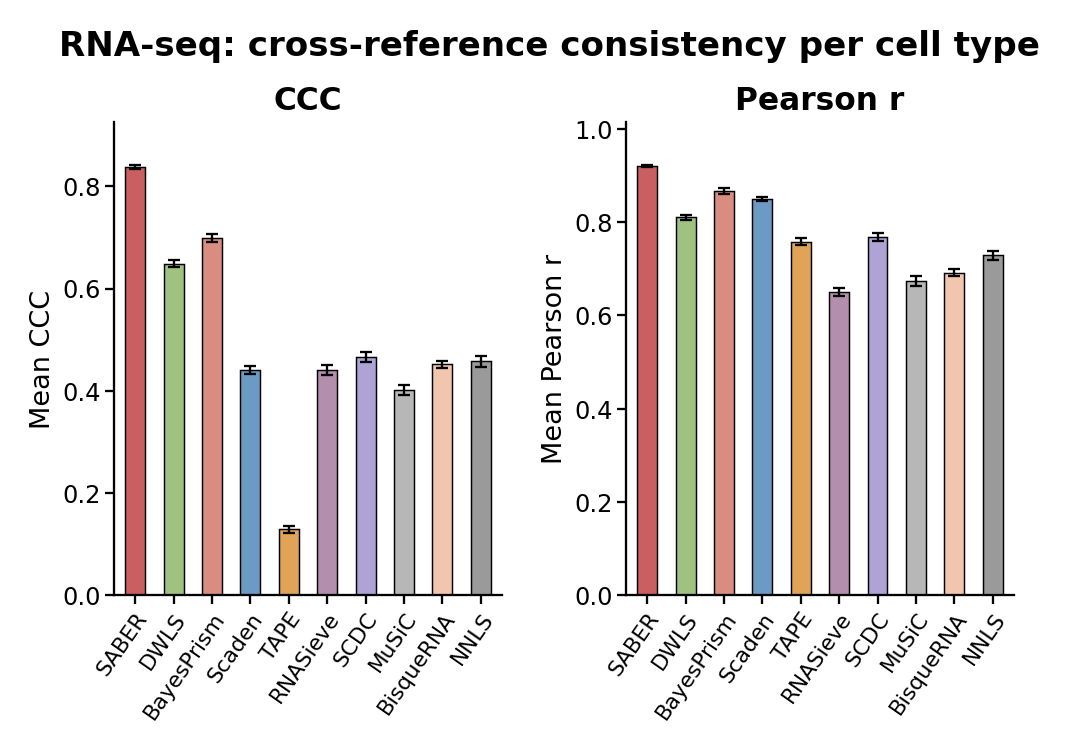

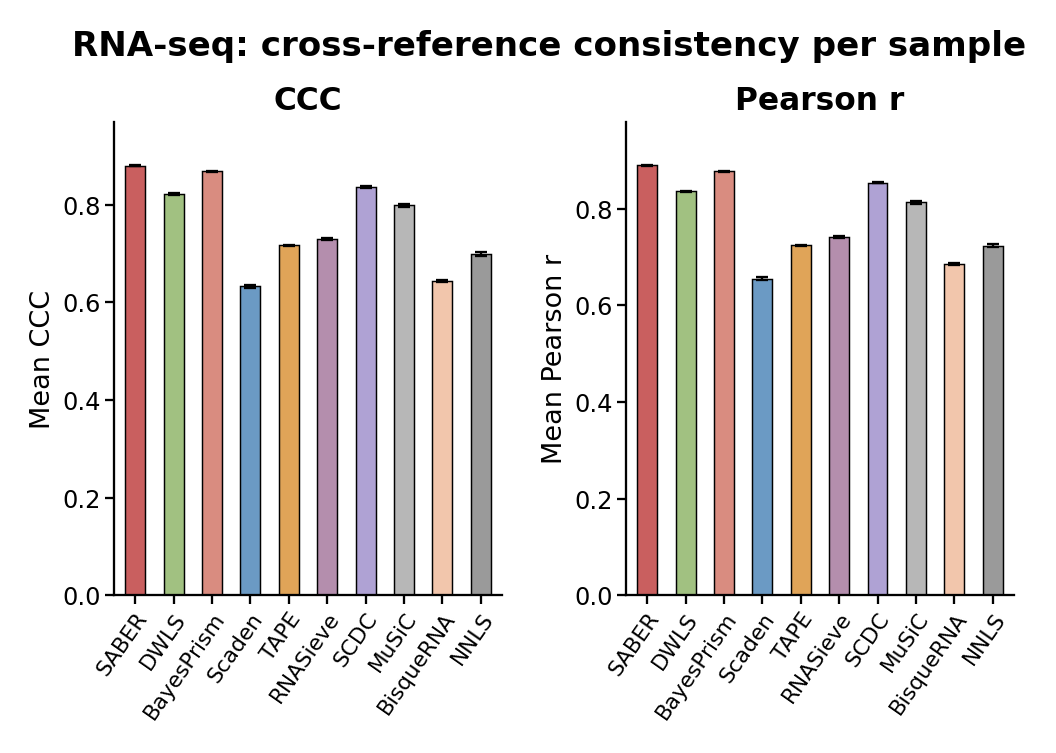

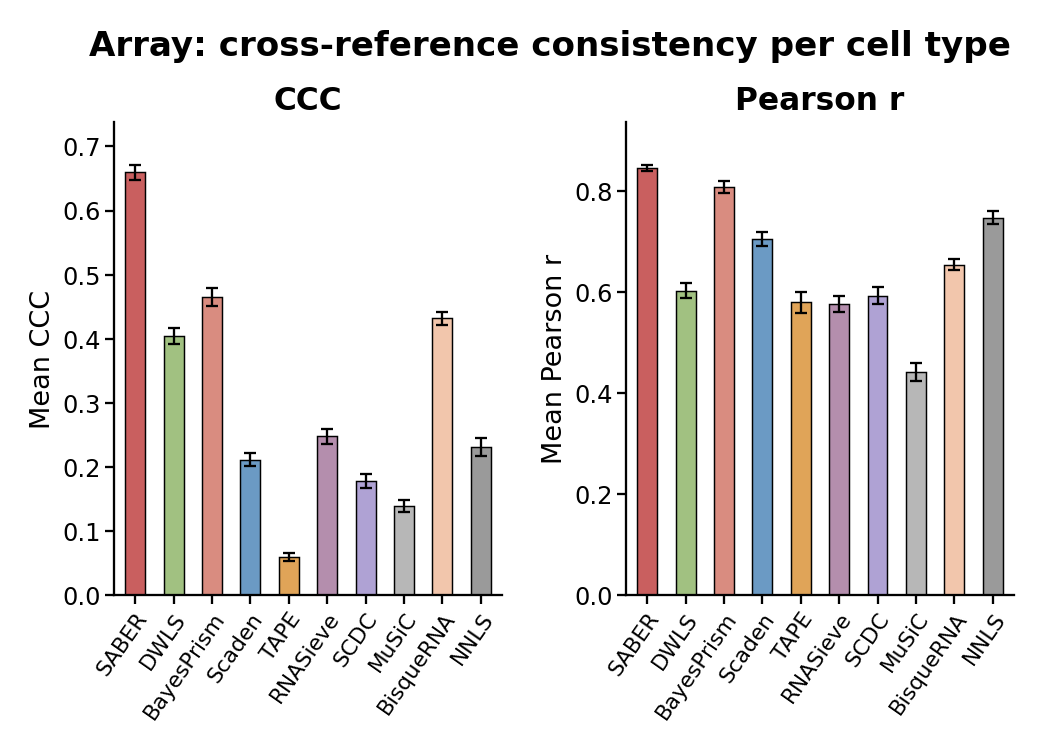

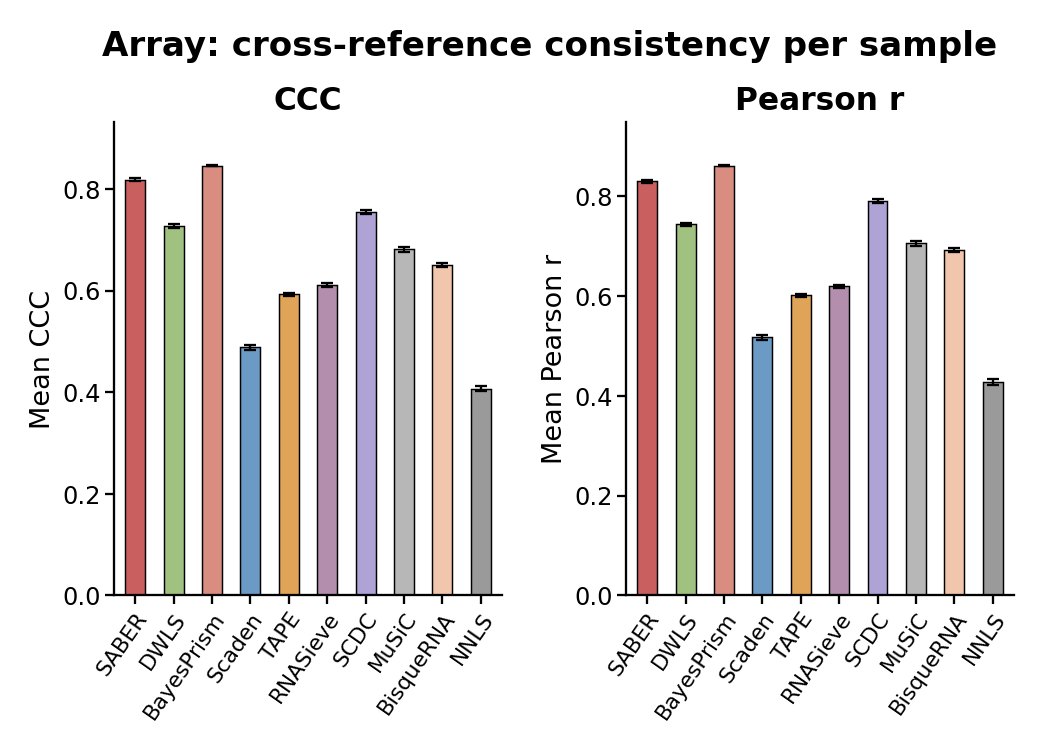

In [5]:
plt.rcParams.update(STYLE_BENCHMARK)


def run_cross_reference_consistency(
    method_list,
    method_colors,
    method_display_names,
    output_dir,
    output_stem,
    include_method_label=False,
):
    os.makedirs(output_dir, exist_ok=True)
    scenarios = {}
    for bulk in BULKS_STANDARD:
        for ref in REF_LIST:
            scenario_name = f"{bulk}_{ref}"
            scenarios[scenario_name] = {
                "bulk": bulk,
                "meta_path": f"/Path/to/IPF/data/{bulk}/metadata.csv",
                "result_dir": f"/Path/to/IPF/results/{bulk}",
                "ref_name": ref,
                "loc_filter": None,
            }
    for bulk in BULKS_WITH_LOC:
        for loc in LOCATIONS:
            for ref in REF_LIST:
                scenario_name = f"{bulk}_{loc}_{ref}"
                scenarios[scenario_name] = {
                    "bulk": bulk,
                    "meta_path": f"/Path/to/IPF/data/{bulk}/metadata.csv",
                    "result_dir": f"/Path/to/IPF/results/{bulk}",
                    "ref_name": ref,
                    "loc_filter": loc,
                }
    dataset_groups = {}
    for scenario_name, cfg in scenarios.items():
        dataset_name = scenario_name.rsplit("_", 1)[0]
        ref_name = cfg["ref_name"]
        if dataset_name not in dataset_groups:
            dataset_groups[dataset_name] = {}
        dataset_groups[dataset_name][ref_name] = scenario_name
    celltype_records = []
    sample_records = []
    qc_records = []
    for dataset_name, refs_dict in dataset_groups.items():
        bulk_name = dataset_name.split("_", 1)[0]
        if bulk_name in RNASEQ_BULKS:
            platform = "RNAseq"
        elif bulk_name in ARRAY_BULKS:
            platform = "Array"
        else:
            qc_records.append(
                {
                    "Dataset": dataset_name,
                    "Method": "ALL",
                    "Ref": "ALL",
                    "Status": "Skipped",
                    "Reason": "Unknown platform",
                }
            )
            continue
        first_cfg = scenarios[refs_dict[REF_LIST[0]]]
        meta_path = first_cfg["meta_path"]
        loc_filter = first_cfg["loc_filter"]
        metadata = pd.read_csv(meta_path, index_col=0)
        metadata = metadata.copy()
        metadata.index = metadata.index.astype(str)
        if loc_filter is not None:
            metadata = metadata[metadata["location"] == loc_filter].copy()
        required_samples = metadata.index.tolist()
        for method in method_list:
            method_preds = {}
            for ref_key in REF_LIST:
                scenario_name = refs_dict[ref_key]
                cfg = scenarios[scenario_name]
                pred_df = pd.read_csv(os.path.join(cfg["result_dir"], f"{method}_{ref_key}.csv"), index_col=0)
                pred_df = pred_df.copy()
                pred_df.index = pred_df.index.astype(str)
                pred_df = pred_df.loc[required_samples, BENCHMARK_CELLTYPES].copy()
                pred_df = pred_df.apply(pd.to_numeric, errors="coerce")
                method_preds[ref_key] = pred_df
                qc_records.append(
                    {
                        "Dataset": dataset_name,
                        "Method": method,
                        "Ref": ref_key,
                        "Status": "Passed",
                        "Reason": "",
                    }
                )
            for ref_A, ref_B in itertools.combinations(REF_LIST, 2):
                df_A = method_preds[ref_A]
                df_B = method_preds[ref_B]
                for ct in BENCHMARK_CELLTYPES:
                    vA = df_A[ct].to_numpy(dtype=float)
                    vB = df_B[ct].to_numpy(dtype=float)
                    n_samples = len(vA)
                    if n_samples < 2:
                        pearson_r = np.nan
                        pearson_status = "Insufficient_n"
                        ccc = np.nan
                        ccc_status = "Insufficient_n"
                    else:
                        std_A = float(np.std(vA, ddof=1))
                        std_B = float(np.std(vB, ddof=1))
                        constant_A = np.isclose(std_A, 0.0, atol=1e-15, rtol=0.0)
                        constant_B = np.isclose(std_B, 0.0, atol=1e-15, rtol=0.0)
                        if constant_A and constant_B:
                            pearson_r = np.nan
                            pearson_status = "Constant_both"
                        elif constant_A:
                            pearson_r = np.nan
                            pearson_status = "Constant_refA"
                        elif constant_B:
                            pearson_r = np.nan
                            pearson_status = "Constant_refB"
                        else:
                            pearson_r, _ = pearsonr(vA, vB)
                            pearson_r = float(pearson_r)
                            pearson_status = "Valid"
                        mean_A = float(np.mean(vA))
                        mean_B = float(np.mean(vB))
                        var_A = float(np.var(vA))
                        var_B = float(np.var(vB))
                        covariance = float(np.mean((vA - mean_A) * (vB - mean_B)))
                        denominator = var_A + var_B + (mean_A - mean_B) ** 2
                        if np.isclose(denominator, 0.0, atol=1e-15, rtol=0.0):
                            ccc = np.nan
                            ccc_status = "Zero_denominator"
                        elif not include_method_label and (constant_A or constant_B):
                            ccc = 0.0
                            ccc_status = "Valid"
                        else:
                            ccc = float(2.0 * covariance / denominator)
                            ccc_status = "Valid"
                    celltype_records.append(
                        {
                            "Evaluation": "PerCellType",
                            "Method": method,
                            **(
                                {"Method_Label": method_display_names[method]}
                                if include_method_label
                                else {}
                            ),
                            "Platform": platform,
                            "Dataset": dataset_name,
                            "Ref_A": ref_A,
                            "Ref_B": ref_B,
                            "CellType": ct,
                            "N_Samples": n_samples,
                            "PearsonR": pearson_r,
                            "Pearson_Status": pearson_status,
                            "CCC": ccc,
                            "CCC_Status": ccc_status,
                        }
                    )
                for sample in required_samples:
                    vA = df_A.loc[sample, BENCHMARK_CELLTYPES].to_numpy(dtype=float)
                    vB = df_B.loc[sample, BENCHMARK_CELLTYPES].to_numpy(dtype=float)
                    n_celltypes = len(BENCHMARK_CELLTYPES)
                    if n_celltypes < 2:
                        pearson_r = np.nan
                        pearson_status = "Insufficient_n"
                        ccc = np.nan
                        ccc_status = "Insufficient_n"
                    else:
                        std_A = float(np.std(vA, ddof=1))
                        std_B = float(np.std(vB, ddof=1))
                        constant_A = np.isclose(std_A, 0.0, atol=1e-15, rtol=0.0)
                        constant_B = np.isclose(std_B, 0.0, atol=1e-15, rtol=0.0)
                        if constant_A and constant_B:
                            pearson_r = np.nan
                            pearson_status = "Constant_both"
                        elif constant_A:
                            pearson_r = np.nan
                            pearson_status = "Constant_refA"
                        elif constant_B:
                            pearson_r = np.nan
                            pearson_status = "Constant_refB"
                        else:
                            pearson_r, _ = pearsonr(vA, vB)
                            pearson_r = float(pearson_r)
                            pearson_status = "Valid"
                        mean_A = float(np.mean(vA))
                        mean_B = float(np.mean(vB))
                        var_A = float(np.var(vA))
                        var_B = float(np.var(vB))
                        covariance = float(np.mean((vA - mean_A) * (vB - mean_B)))
                        denominator = var_A + var_B + (mean_A - mean_B) ** 2
                        if np.isclose(denominator, 0.0, atol=1e-15, rtol=0.0):
                            ccc = np.nan
                            ccc_status = "Zero_denominator"
                        elif not include_method_label and (constant_A or constant_B):
                            ccc = 0.0
                            ccc_status = "Valid"
                        else:
                            ccc = float(2.0 * covariance / denominator)
                            ccc_status = "Valid"
                    sample_records.append(
                        {
                            "Evaluation": "PerSample",
                            "Method": method,
                            **(
                                {"Method_Label": method_display_names[method]}
                                if include_method_label
                                else {}
                            ),
                            "Platform": platform,
                            "Dataset": dataset_name,
                            "Ref_A": ref_A,
                            "Ref_B": ref_B,
                            "Sample": sample,
                            "N_CellTypes": n_celltypes,
                            "PearsonR": pearson_r,
                            "Pearson_Status": pearson_status,
                            "CCC": ccc,
                            "CCC_Status": ccc_status,
                        }
                    )
    df_celltype = pd.DataFrame(celltype_records)
    df_sample = pd.DataFrame(sample_records)
    qc_df = pd.DataFrame(qc_records)
    qc_df.to_csv(os.path.join(output_dir, f"{output_stem}_cross_reference_consistency_QC.csv"), index=False)

    def summarize(raw_df, evaluation):
        records = []
        for method in method_list:
            method_df = raw_df[raw_df["Method"] == method]
            total = len(method_df)
            for metric, status_column in [("PearsonR", "Pearson_Status"), ("CCC", "CCC_Status")]:
                valid_mask = (method_df[status_column] == "Valid") & np.isfinite(
                    pd.to_numeric(method_df[metric], errors="coerce")
                )
                values = pd.to_numeric(method_df.loc[valid_mask, metric], errors="coerce").dropna()
                valid = len(values)
                if valid == 0:
                    mean_value = sd = sem = np.nan
                elif valid == 1:
                    mean_value = float(values.mean())
                    sd = sem = 0.0
                else:
                    mean_value = float(values.mean())
                    sd = float(values.std(ddof=1))
                    sem = float(sd / np.sqrt(valid))
                status_counts = method_df[status_column].value_counts()
                records.append(
                    {
                        "Evaluation": evaluation,
                        "Method": method,
                        **(
                            {"Method_Label": method_display_names[method]}
                            if include_method_label
                            else {}
                        ),
                        "Metric": metric,
                        "Mean": mean_value,
                        "SD": sd,
                        "SEM": sem,
                        "Valid_Count": valid,
                        "Total_Count": total,
                        "Undefined_Count": total - valid,
                        "Valid_Rate": valid / total,
                        "Undefined_Rate": (total - valid) / total,
                        "Constant_refA_Count": int(status_counts.get("Constant_refA", 0)),
                        "Constant_refB_Count": int(status_counts.get("Constant_refB", 0)),
                        "Constant_both_Count": int(status_counts.get("Constant_both", 0)),
                        "Insufficient_n_Count": int(status_counts.get("Insufficient_n", 0)),
                        "Zero_denominator_Count": int(status_counts.get("Zero_denominator", 0))
                        if metric == "CCC"
                        else 0,
                    }
                )
        return pd.DataFrame(records)

    def plot_summary(summary_df, platform_label, unit, filename_key):
        available_methods = [
            method for method in method_list if method in summary_df["Method"].unique()
        ]
        x = np.arange(len(available_methods)) * 0.58
        colors = [method_colors[method] for method in available_methods]
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(max(3.87, 0.18 * len(available_methods) * 2), 2.05),
            gridspec_kw={"wspace": 0.32},
        )
        for ax, (metric, panel_title, y_label) in zip(
            axes, [("CCC", "CCC", "Mean CCC"), ("PearsonR", "Pearson r", "Mean Pearson r")]
        ):
            panel_df = (
                summary_df[summary_df["Metric"] == metric]
                .set_index("Method")
                .reindex(available_methods)
            )
            means = panel_df["Mean"].astype(float).values
            sems = panel_df["SEM"].astype(float).fillna(0.0).values
            ax.bar(
                x,
                means,
                yerr=sems,
                color=colors,
                edgecolor="black",
                linewidth=0.35,
                width=0.3,
                error_kw={"elinewidth": 0.55, "ecolor": "black", "capsize": 1.5, "capthick": 0.55},
            )
            ax.set_title(panel_title, pad=3)
            ax.set_ylabel(y_label, labelpad=1.5)
            ax.set_xticks(x)
            ax.set_xticklabels(
                [method_display_names.get(method, method) for method in available_methods],
                rotation=55,
                ha="right",
                rotation_mode="anchor",
            )
            ax.set_xlim(x[0] - 0.32, x[-1] + 0.32)
            observed_max = float(np.max((means + sems)[np.isfinite(means + sems)]))
            ax.set_ylim(0, max(observed_max * 1.1, observed_max + 0.02, 0.1))
            ax.tick_params(
                axis="both", which="both", direction="out", length=2.2, width=0.55, pad=1.0
            )
            ax.spines["left"].set_linewidth(0.55)
            ax.spines["bottom"].set_linewidth(0.55)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
        fig.suptitle(
            f"{platform_label}: cross-reference consistency per {'cell type' if unit == 'celltype' else 'sample'}",
            fontsize=8.2,
            fontweight="bold",
            y=1.03,
        )
        plt.tight_layout(pad=0.35, w_pad=0.3)
        fig.savefig(
            os.path.join(
                output_dir, f"{output_stem}_{filename_key}_per_{unit}_consistency_barplot.pdf"
            ),
            bbox_inches="tight",
        )
        plt.show()

    for platform_key, platform_label in PLATFORM_LABELS.items():
        filename_key = platform_key.lower()
        for unit, evaluation, raw_df in [
            ("celltype", "PerCellType", df_celltype[df_celltype["Platform"] == platform_key]),
            ("sample", "PerSample", df_sample[df_sample["Platform"] == platform_key]),
        ]:
            raw_df.to_csv(
                os.path.join(
                    output_dir, f"{output_stem}_{filename_key}_per_{unit}_consistency_raw.csv"
                ),
                index=False,
            )
            summary_df = summarize(raw_df, f"{platform_label}_{evaluation}")
            summary_df.to_csv(
                os.path.join(
                    output_dir, f"{output_stem}_{filename_key}_per_{unit}_consistency_summary.csv"
                ),
                index=False,
            )
            plot_summary(summary_df, platform_label, unit, filename_key)


run_cross_reference_consistency(
    list(BENCHMARK_METHOD_COLORS),
    BENCHMARK_METHOD_COLORS,
    SCATTER_METHOD_DISPLAY_NAMES,
    "/Path/to/output/IPF/consistency",
    "IPF",
)


## Ablation cross-reference consistency

Repeat the same consistency workflow for SABER ablations while preserving the benchmark statistical definitions and output schema.

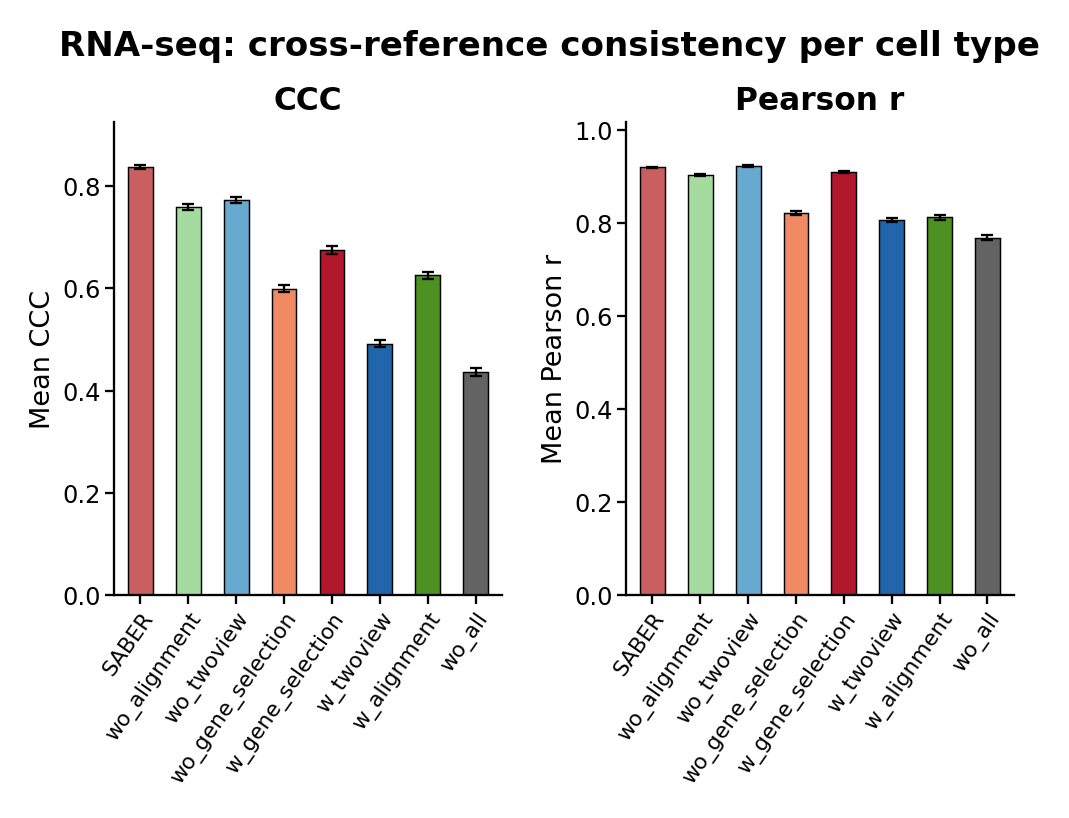

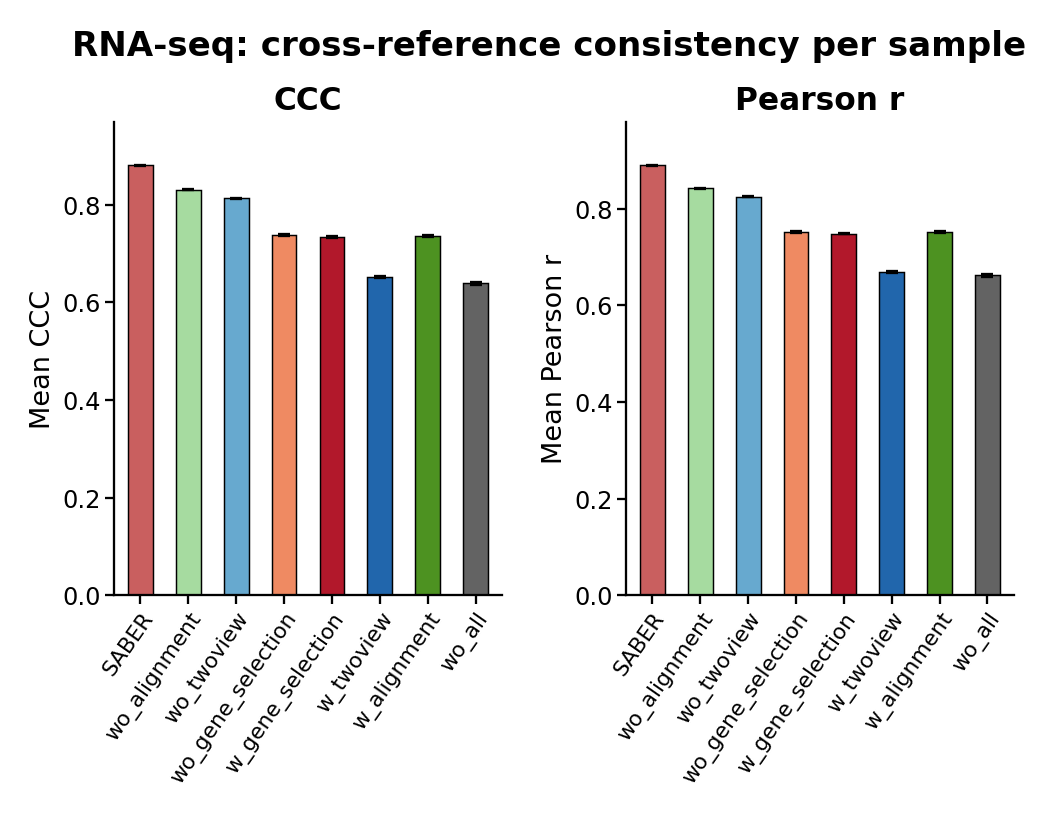

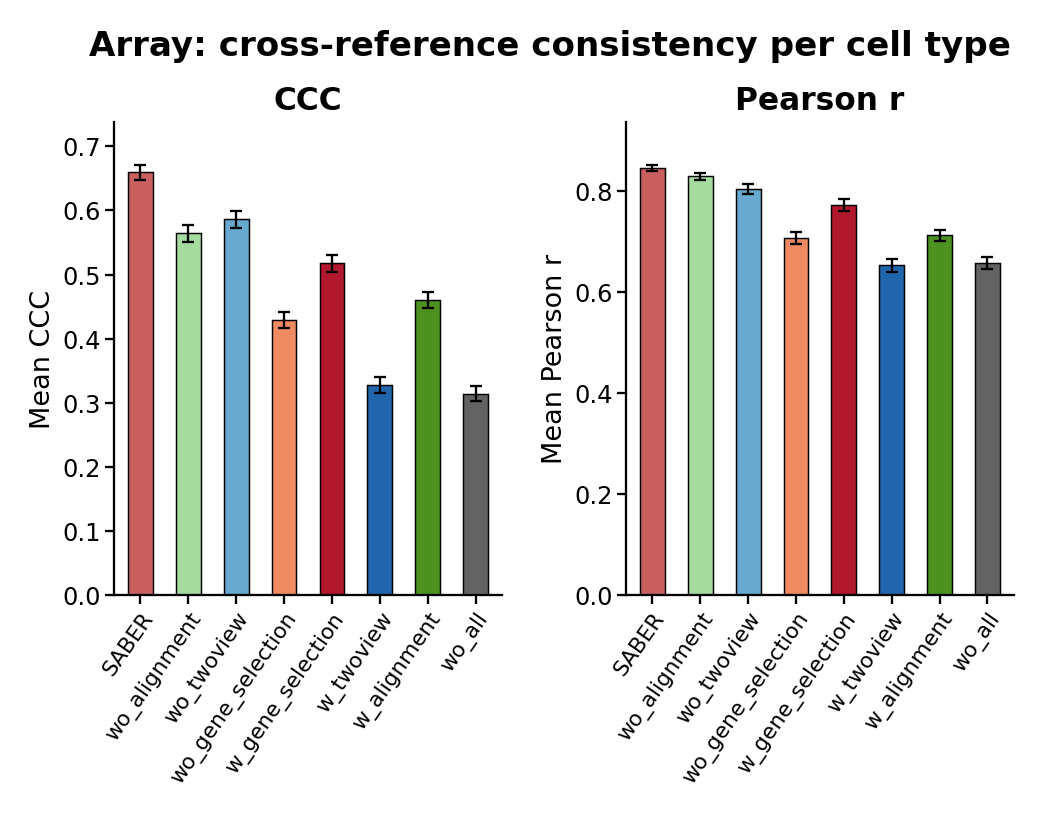

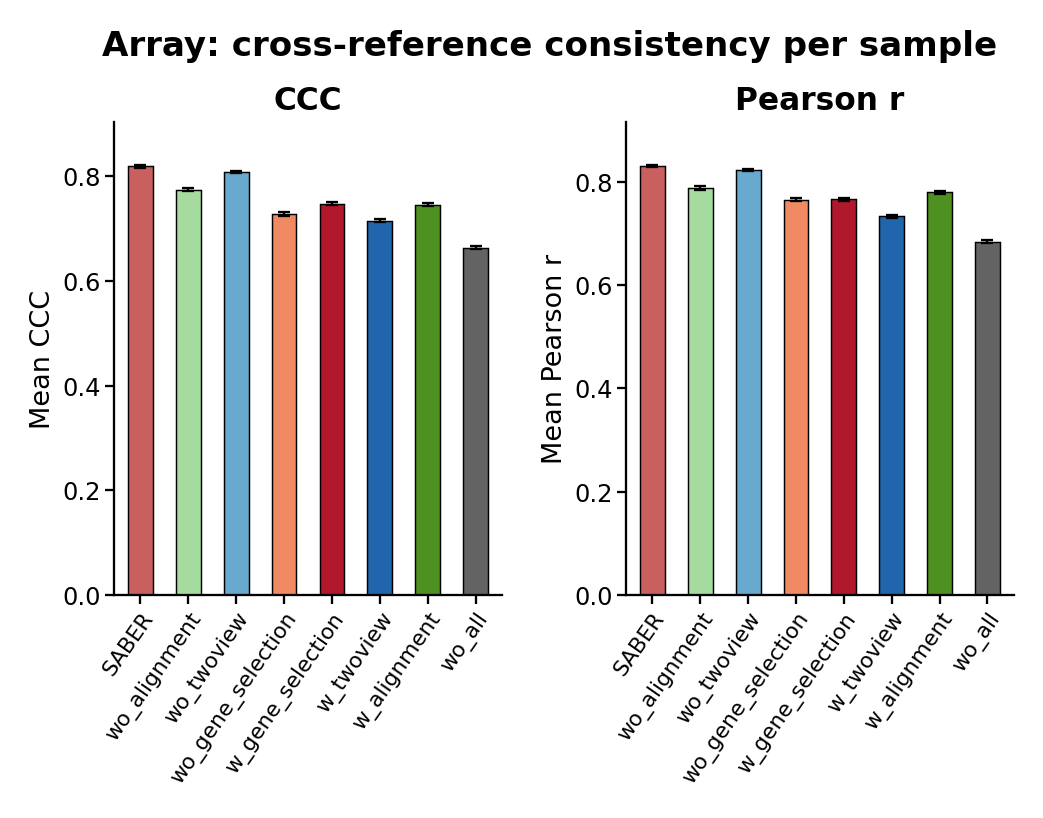

In [6]:
plt.rcParams.update(STYLE_BENCHMARK)
run_cross_reference_consistency(
    [
        "SABER", "SABER_wo_alignment", "SABER_wo_twoview", "SABER_wo_gene_selection",
        "SABER_w_gene_selection", "SABER_w_twoview", "SABER_w_alignment", "SABER_wo_all",
    ],
    {
        "SABER": "#C95F5F", "SABER_wo_alignment": "#A6DBA0", "SABER_wo_twoview": "#67A9CF",
        "SABER_wo_gene_selection": "#EF8A62", "SABER_w_gene_selection": "#B2182B",
        "SABER_w_twoview": "#2166AC", "SABER_w_alignment": "#4D9221", "SABER_wo_all": "#636363",
    },
    {
        "SABER": "SABER", "SABER_w_gene_selection": "w_gene_selection",
        "SABER_wo_gene_selection": "wo_gene_selection", "SABER_w_twoview": "w_twoview",
        "SABER_wo_twoview": "wo_twoview", "SABER_w_alignment": "w_alignment",
        "SABER_wo_alignment": "wo_alignment", "SABER_wo_all": "wo_all",
    },
    "/Path/to/output/IPF/consistency_ablation",
    "IPF_ablation",
    True,
)
